In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical


2025-11-29 17:09:49.398830: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
df = pd.read_csv("data/news_sentiment_final.csv")

df["sentiment"] = df["sentiment"].astype(int)
X = df["clean_content"].astype(str)
y = df["sentiment"] - 1   # 0–4

num_classes = 5
df.head()


,source,title,description,content,clean_content,sentiment
0,Al Jazeera,What is the political agenda of artificial int...,"May 17, 2023 ... We do not believe that it cou...",Could AI single-handedly decide the course of ...,Could AI single-handedly decide the course of ...,1
1,Al Jazeera,Facebook reveals AI use to block 'terrorist co...,"Jun 16, 2017 ... Facebook says it has stepped ...",US company says technology used to block child...,US company says technology used to block child...,1
2,Al Jazeera,Could artificial intelligence lead to world pe...,"May 30, 2017 ... Machines and artificial intel...",Can one man with terminal cancer complete his ...,Can one man with terminal cancer complete his ...,4
3,Al Jazeera,Artificial intelligence without borders | US-M...,"Jun 9, 2023 ... The US-Mexico border is alread...",The US border-industrial complex has joined th...,The US border-industrial complex has joined th...,4
4,Al Jazeera,Google shows the AI evolution of its search en...,"May 11, 2023 ... Google is rolling out more ar...",Google is rolling out more artificial intellig...,Google is rolling out more artificial intellig...,5


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [4]:
max_words = 50000
max_len = 300   # sequence length

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_test_pad  = pad_sequences(X_test_seq, maxlen=max_len, padding='post')

y_train_cat = to_categorical(y_train, num_classes)
y_test_cat  = to_categorical(y_test, num_classes)

vocab_size = min(max_words, len(tokenizer.word_index) + 1)
vocab_size


42402

In [5]:
model_bilstm = Sequential([
    Embedding(input_dim=vocab_size, output_dim=128, input_length=max_len),
    Bidirectional(LSTM(128, return_sequences=False)),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

model_bilstm.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model_bilstm.summary()

/Users/shoaib/Desktop/University/5th Semester/NLP/Project/venv/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [6]:
history_bilstm = model_bilstm.fit(
    X_train_pad, y_train_cat,
    validation_split=0.2,
    epochs=5,
    batch_size=128
)


Epoch 1/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 21s 975ms/step - accuracy: 0.4138 - loss: 1.3791 - val_accuracy: 0.4331 - val_loss: 1.1775
Epoch 2/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 18s 983ms/step - accuracy: 0.4632 - loss: 1.1416 - val_accuracy: 0.5493 - val_loss: 1.0894
Epoch 3/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.6602 - loss: 0.8805 - val_accuracy: 0.7447 - val_loss: 0.6993
Epoch 4/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 17s 948ms/step - accuracy: 0.8744 - loss: 0.3996 - val_accuracy: 0.8081 - val_loss: 0.5581
Epoch 5/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 18s 985ms/step - accuracy: 0.9550 - loss: 0.1749 - val_accuracy: 0.8380 - val_loss: 0.5865


In [7]:
y_proba_bilstm = model_bilstm.predict(X_test_pad)
y_pred_bilstm = np.argmax(y_proba_bilstm, axis=1)

print("BiLSTM Model Evaluation Complete.")


23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step
BiLSTM Model Evaluation Complete.


In [8]:
y_pred_bilstm = np.argmax(y_proba_bilstm, axis=1)
num_classes = 5
y_test_oh = np.eye(num_classes)[y_test]


In [9]:
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, roc_auc_score, top_k_accuracy_score
)


In [10]:
# Accuracy = Exact Match (EM)
accuracy_bilstm = accuracy_score(y_test, y_pred_bilstm)

# Precision, Recall, F1 (macro for balanced performance)
precision_bilstm, recall_bilstm, f1_bilstm, _ = precision_recall_fscore_support(
    y_test, y_pred_bilstm, average='macro'
)

# AUC (macro, One-vs-Rest)
auc_bilstm = roc_auc_score(
    y_test_oh,
    y_proba_bilstm,
    multi_class='ovr',
    average='macro'
)

# Top-K Accuracy (Top-3 is usually standard)
top3_bilstm = top_k_accuracy_score(y_test, y_proba_bilstm, k=3)

# Confusion Matrix
cm_bilstm = confusion_matrix(y_test, y_pred_bilstm)

print("=== BiLSTM Evaluation Metrics ===")

print(f"Accuracy (Exact Match): {accuracy_bilstm:.4f}")
print(f"Precision (Macro):      {precision_bilstm:.4f}")
print(f"Recall (Macro):         {recall_bilstm:.4f}")
print(f"F1-Score (Macro):       {f1_bilstm:.4f}")
print(f"AUC (Macro OVR):        {auc_bilstm:.4f}")
print(f"Top-3 Accuracy:         {top3_bilstm:.4f}")

print("\nConfusion Matrix:\n")
print(cm_bilstm)


=== BiLSTM Evaluation Metrics ===
Accuracy (Exact Match): 0.8282
Precision (Macro):      0.6391
Recall (Macro):         0.6135
F1-Score (Macro):       0.6242
AUC (Macro OVR):        0.9415
Top-3 Accuracy:         0.9732

Confusion Matrix:

[[235   6   0  35   0]
 [  7  70   0  20   3]
 [  1   3   0   1   0]
 [ 13  20   0 264   2]
 [  5   3   0   3  19]]


/Users/shoaib/Desktop/University/5th Semester/NLP/Project/venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [24]:
import pandas as pd

# Create a dictionary of the metrics
metrics_dict = {
    "Metric": [
        "Accuracy (Exact Match)",
        "Precision (Macro)",
        "Recall (Macro)",
        "F1-Score (Macro)",
        "AUC (Macro OVR)",
        "Top-3 Accuracy"
    ],
    "Value": [
        accuracy_bilstm,
        precision_bilstm,
        recall_bilstm,
        f1_bilstm,
        auc_bilstm,
        top3_bilstm
    ]
}

# Convert to DataFrame
metrics_df = pd.DataFrame(metrics_dict)

# Save to CSV
metrics_df.to_csv("bilstm_evaluation_metrics.csv", index=False)

metrics_df


,Metric,Value
0,Accuracy (Exact Match),0.828169
1,Precision (Macro),0.639132
2,Recall (Macro),0.613545
3,F1-Score (Macro),0.624176
4,AUC (Macro OVR),0.941472
5,Top-3 Accuracy,0.973239


In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(true_labels, pred_labels, title, cmap="Blues"):
    cm = confusion_matrix(true_labels, pred_labels)

    plt.figure(figsize=(7,5))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap=cmap,
        xticklabels=[0,1,2,3,4], 
        yticklabels=[0,1,2,3,4]
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.show()


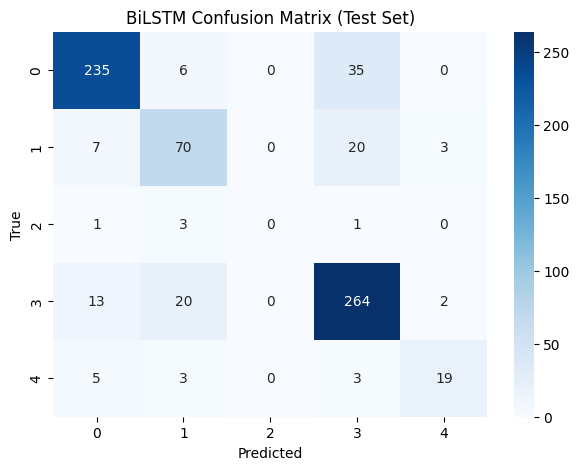

In [13]:
plot_confusion_matrix(
    y_test,
    y_pred_bilstm,
    title="BiLSTM Confusion Matrix (Test Set)",
    cmap="Blues"
)


In [14]:
import numpy as np

from tensorflow.keras.layers import (
    Input, Embedding, Conv1D, GlobalMaxPooling1D,
    Concatenate, Dense, Dropout
)
from tensorflow.keras.models import Model

from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, roc_auc_score, top_k_accuracy_score
)


In [15]:
# If num_classes not defined, uncomment this:
# num_classes = y_train_cat.shape[1]

embedding_dim = 128  # you can increase later if you want

input_layer = Input(shape=(max_len,))

embedding_layer = Embedding(
    input_dim=vocab_size,
    output_dim=embedding_dim,
    input_length=max_len,
    trainable=True
)(input_layer)

# Convolution layers with different kernel sizes
conv3 = Conv1D(128, kernel_size=3, activation='relu')(embedding_layer)
conv4 = Conv1D(128, kernel_size=4, activation='relu')(embedding_layer)
conv5 = Conv1D(128, kernel_size=5, activation='relu')(embedding_layer)

pool3 = GlobalMaxPooling1D()(conv3)
pool4 = GlobalMaxPooling1D()(conv4)
pool5 = GlobalMaxPooling1D()(conv5)

merged = Concatenate()([pool3, pool4, pool5])

dense = Dense(128, activation='relu')(merged)
dropout = Dropout(0.4)(dense)
output = Dense(num_classes, activation='softmax')(dropout)

model_cnn = Model(inputs=input_layer, outputs=output)

model_cnn.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model_cnn.summary()

/Users/shoaib/Desktop/University/5th Semester/NLP/Project/venv/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 300)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 300, 128)  │  5,427,456 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 298, 128)  │     49,280 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 297, 128)  │     65,664 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 296, 128)  │     82,048 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_1[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_2[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 384)       │          0 │ global_max_pooli… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
│                     │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │     49,280 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 5)         │        645 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,674,373 (21.65 MB)

 Trainable params: 5,674,373 (21.65 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
history_cnn = model_cnn.fit(
    X_train_pad,
    y_train_cat,
    validation_split=0.2,
    epochs=5,          # can increase to 8–10 later
    batch_size=128
)


Epoch 1/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 347ms/step - accuracy: 0.4592 - loss: 1.2662 - val_accuracy: 0.7165 - val_loss: 1.0890
Epoch 2/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 293ms/step - accuracy: 0.6408 - loss: 1.0043 - val_accuracy: 0.7324 - val_loss: 0.9090
Epoch 3/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 318ms/step - accuracy: 0.7625 - loss: 0.7485 - val_accuracy: 0.7658 - val_loss: 0.6998
Epoch 4/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 310ms/step - accuracy: 0.8506 - loss: 0.4999 - val_accuracy: 0.8275 - val_loss: 0.5465
Epoch 5/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 317ms/step - accuracy: 0.9224 - loss: 0.2981 - val_accuracy: 0.8504 - val_loss: 0.4524


In [17]:
y_proba_cnn = model_cnn.predict(X_test_pad)
y_pred_cnn = np.argmax(y_proba_cnn, axis=1)

print("TextCNN predictions done.")


23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
TextCNN predictions done.


In [18]:
# One-hot labels for AUC
num_classes = y_train_cat.shape[1]  # just to be safe
y_test_oh = np.eye(num_classes)[y_test]

# Accuracy = Exact Match
accuracy_cnn = accuracy_score(y_test, y_pred_cnn)

# Macro precision / recall / F1
precision_cnn, recall_cnn, f1_cnn, _ = precision_recall_fscore_support(
    y_test, y_pred_cnn, average='macro'
)

# Macro AUC (one-vs-rest)
auc_cnn = roc_auc_score(
    y_test_oh,
    y_proba_cnn,
    multi_class='ovr',
    average='macro'
)

# Top-k accuracy (k = 3)
top3_cnn = top_k_accuracy_score(y_test, y_proba_cnn, k=3)

# Confusion matrix
cm_cnn = confusion_matrix(y_test, y_pred_cnn)

print("=== TextCNN Evaluation Metrics ===")
print(f"Accuracy (Exact Match): {accuracy_cnn:.4f}")
print(f"Precision (Macro):      {precision_cnn:.4f}")
print(f"Recall (Macro):         {recall_cnn:.4f}")
print(f"F1-Score (Macro):       {f1_cnn:.4f}")
print(f"AUC (Macro OVR):        {auc_cnn:.4f}")
print(f"Top-3 Accuracy:         {top3_cnn:.4f}")
print("\nConfusion Matrix:\n", cm_cnn)


=== TextCNN Evaluation Metrics ===
Accuracy (Exact Match): 0.8732
Precision (Macro):      0.7404
Recall (Macro):         0.6014
F1-Score (Macro):       0.6442
AUC (Macro OVR):        0.9481
Top-3 Accuracy:         0.9732

Confusion Matrix:
 [[266   0   0  10   0]
 [ 17  66   0  17   0]
 [  1   0   0   4   0]
 [ 25   0   0 274   0]
 [  7   1   0   8  14]]


/Users/shoaib/Desktop/University/5th Semester/NLP/Project/venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [25]:
import pandas as pd

# Create a dictionary for CNN metrics
cnn_metrics_dict = {
    "Metric": [
        "Accuracy (Exact Match)",
        "Precision (Macro)",
        "Recall (Macro)",
        "F1-Score (Macro)",
        "AUC (Macro OVR)",
        "Top-3 Accuracy"
    ],
    "Value": [
        accuracy_cnn,
        precision_cnn,
        recall_cnn,
        f1_cnn,
        auc_cnn,
        top3_cnn
    ]
}

# Convert to DataFrame
cnn_metrics_df = pd.DataFrame(cnn_metrics_dict)

# Save to CSV
cnn_metrics_df.to_csv("cnn_evaluation_metrics.csv", index=False)

cnn_metrics_df


,Metric,Value
0,Accuracy (Exact Match),0.873239
1,Precision (Macro),0.740449
2,Recall (Macro),0.601365
3,F1-Score (Macro),0.644171
4,AUC (Macro OVR),0.948051
5,Top-3 Accuracy,0.973239


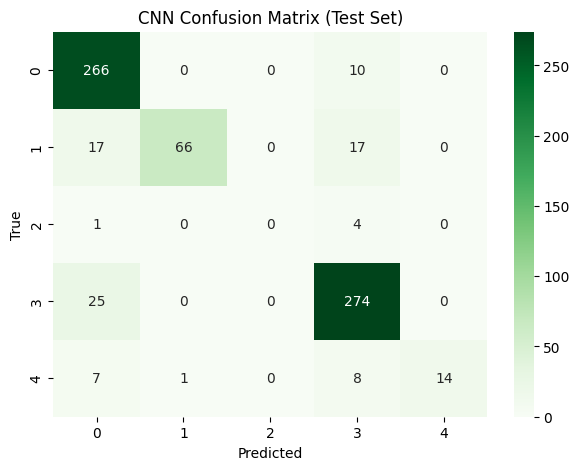

In [22]:
plot_confusion_matrix(
    y_test,
    y_pred_cnn,
    title="CNN Confusion Matrix (Test Set)",
    cmap="Greens"
)


In [19]:
model_bilstm.save("models/bilstm_model.h5")

import joblib
joblib.dump(tokenizer, "models/tokenizer_bilstm.pkl")

print("Saved: bilstm_model.h5, tokenizer_bilstm.pkl")

model_cnn.save("models/textcnn_model.h5")
print("Saved: textcnn_model.h5")


Saved: bilstm_model.h5, tokenizer_bilstm.pkl
Saved: textcnn_model.h5


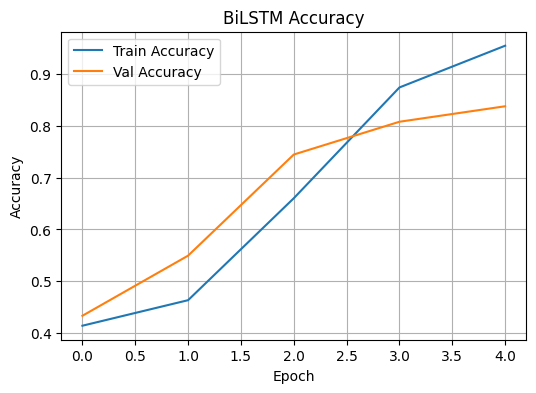

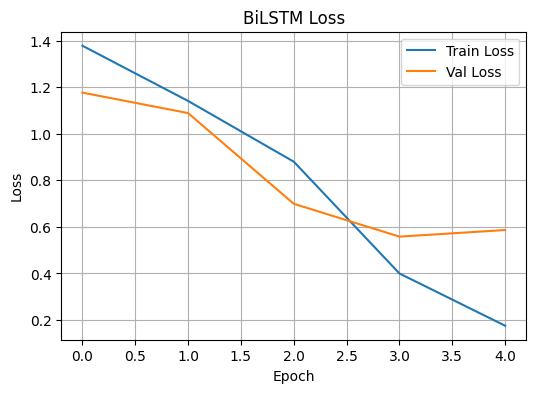

In [20]:
import matplotlib.pyplot as plt

# --- Accuracy ---
plt.figure(figsize=(6,4))
plt.plot(history_bilstm.history["accuracy"], label="Train Accuracy")
plt.plot(history_bilstm.history["val_accuracy"], label="Val Accuracy")
plt.title("BiLSTM Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# --- Loss ---
plt.figure(figsize=(6,4))
plt.plot(history_bilstm.history["loss"], label="Train Loss")
plt.plot(history_bilstm.history["val_loss"], label="Val Loss")
plt.title("BiLSTM Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


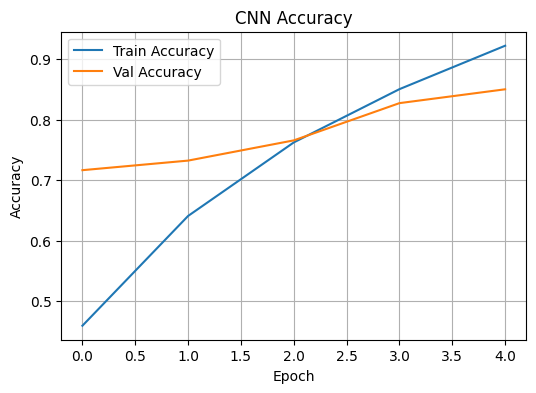

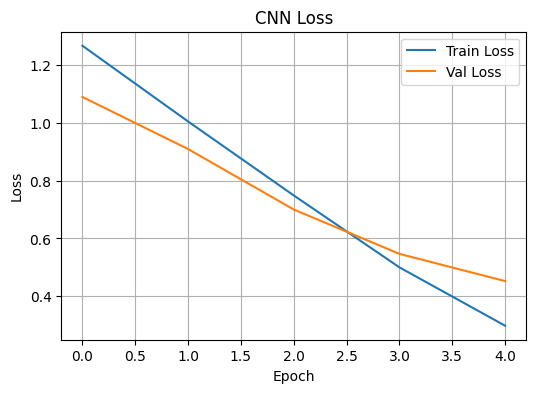

In [21]:
# --- Accuracy ---
plt.figure(figsize=(6,4))
plt.plot(history_cnn.history["accuracy"], label="Train Accuracy")
plt.plot(history_cnn.history["val_accuracy"], label="Val Accuracy")
plt.title("CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# --- Loss ---
plt.figure(figsize=(6,4))
plt.plot(history_cnn.history["loss"], label="Train Loss")
plt.plot(history_cnn.history["val_loss"], label="Val Loss")
plt.title("CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()
